# 03 — Inferential Analysis

**Note**: $n=41$ → low statistical power. Results are **exploratory**, not confirmatory.

**Pipeline**:
1. Mann–Whitney U (Wilcoxon Rank Sum) + Cliff's Delta (magnitude per Romano et al., 2006) for 4 subgroup pairs × 13 characteristics × 2 dimensions (importance and priority)
2. Spearman ρ between n_projects/seniority_ordinal and each Likert (with bootstrap CI)
3. Holm–Bonferroni for multiple comparisons
4. Paired Wilcoxon signed-rank to test the importance–priority gap
5. Friedman + Nemenyi post-hoc for global ranking of characteristics
6. Output: `tables/inferential.tex` consolidating significant findings

**Subgroups**:
- Seniors (Mid+Senior, n=20) vs Juniors (Intern+Junior, n=12)
- Data scientists (n=18) vs Developers (n=9)
- More experienced (>3 projects) vs Less experienced (≤3 projects)
- Men (n=24) vs Women (n=8) — bonus, but report with caution

## 1. Setup & Imports

In [50]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

TABLES = U.DATA_PROC / "tables"
df = U.load_anonymized()
print(f"N={len(df)}")

N=41


## 3. Significance Analysis and Effect Size

### 3.1 Helper: Mann–Whitney U + Cliff's Delta

Wraps `scipy.stats.mannwhitneyu` (two-sided) with Cliff's Delta and BCa bootstrap 95% CI.

In [51]:
def mwu_delta(g1: pd.Series, g2: pd.Series, n_boot: int = 10_000) -> dict:
    g1 = g1.dropna().astype(float)
    g2 = g2.dropna().astype(float)
    if len(g1) < 2 or len(g2) < 2:
        return {"U": np.nan, "p": np.nan, "delta": np.nan,
                "ci_lo": np.nan, "ci_hi": np.nan, "ci_method": "insufficient",
                "magnitude": "insufficient", "n1": len(g1), "n2": len(g2),
                "med1": np.nan, "med2": np.nan}
    U_stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    cd = U.cliffs_delta_with_ci(g1, g2, n_resamples=n_boot)
    return {"U": float(U_stat), "p": float(p),
            "delta": cd["delta"], "ci_lo": cd["ci_lo"], "ci_hi": cd["ci_hi"],
            "ci_method": cd["method"], "magnitude": cd["magnitude"],
            "n1": int(len(g1)), "n2": int(len(g2)),
            "med1": float(g1.median()), "med2": float(g2.median())}


Defines the 4 subgroup pairs and collects Mann–Whitney U + Cliff's Delta for each pair × each Likert column (importance and priority), totaling **4 × 13 × 2 = 104** tests.

In [52]:
comparisons = [
    ("Seniors × Juniors",
     df[df["seniority_group"] == "senior"], df[df["seniority_group"] == "junior"]),
    ("Data scientists × Developers",
     df[df["role_group"] == "data_scientist"], df[df["role_group"] == "developer"]),
    (">3 projects × ≤3 projects",
     df[df["n_projects"] > 3], df[df["n_projects"] <= 3]),
    ("Men × Women",
     df[df["gender_norm"] == "male"], df[df["gender_norm"] == "female"]),
]

def collect_tests(comparisons, cols, dim_label):
    rows = []
    for comp_name, g1, g2 in comparisons:
        for col in cols:
            char = col.split("_", 1)[1]
            r = mwu_delta(g1[col], g2[col])
            rows.append({"dim": dim_label, "comparison": comp_name,
                         "characteristic": char, **r})
    return pd.DataFrame(rows)

imp_tests = collect_tests(comparisons, U.IMP_COLS, "importance")
pri_tests = collect_tests(comparisons, U.PRI_COLS, "priority")
tests = pd.concat([imp_tests, pri_tests], ignore_index=True)
print(f"Total tests executed: {len(tests)}")

Total tests executed: 104


### 3.2 Holm–Bonferroni Correction

Applied **within each comparison-pair × dimension** (avoids over-correcting across unrelated comparisons).

In [53]:
def add_holm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (comp, dim), grp in out.groupby(["comparison", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

tests = add_holm(tests)
sig_raw  = tests[tests["sig_raw"]]
sig_holm = tests[tests["sig_holm"]]
interesting = (tests[(tests["sig_raw"]) & (tests["delta"].abs() >= 0.33)]
               .sort_values("delta", key=abs, ascending=False))

print(f"Significant (raw p<0.05): {len(sig_raw)}")
print(f"Significant after Holm:   {len(sig_holm)}")



Significant (raw p<0.05): 14
Significant after Holm:   4


All significant tests

In [54]:
_disp_cols = ["dim", "comparison", "characteristic",
              "delta", "magnitude"]

display(
    interesting.loc[interesting["sig_holm"] == False, _disp_cols]
    .reset_index(drop=True)
)

,dim,comparison,characteristic,delta,magnitude
0,priority,Data scientists × Developers,currentness,0.512397,large
1,priority,>3 projects × ≤3 projects,availability,-0.490338,large
2,priority,>3 projects × ≤3 projects,compliance,-0.478261,large
3,importance,>3 projects × ≤3 projects,recoverability,-0.468599,medium
4,priority,Men × Women,credibility,-0.451613,medium
5,priority,Seniors × Juniors,efficiency,-0.404306,medium
6,priority,Men × Women,availability,-0.403226,medium
7,importance,>3 projects × ≤3 projects,reliability,-0.376812,medium
8,priority,>3 projects × ≤3 projects,accessibility,-0.357488,medium
9,priority,Seniors × Juniors,availability,-0.351675,medium


Testes that passed holm

In [55]:
display(
    interesting.loc[interesting["sig_holm"] == True, _disp_cols]
    .reset_index(drop=True)
)

,dim,comparison,characteristic,delta,magnitude
0,priority,>3 projects × ≤3 projects,efficiency,-0.623188,large
1,importance,>3 projects × ≤3 projects,efficiency,-0.555556,large
2,priority,>3 projects × ≤3 projects,recoverability,-0.550725,large
3,priority,>3 projects × ≤3 projects,reliability,-0.487923,large


## 4. Spearman ρ — Correlation with n_projects and Seniority

Correlation ρ by characteristic between n_projects/seniority_ordinal and each Likert (Q11/Q13).

- **Paired bootstrap 95% CI** (BCa, 10k resamples; fallback to percentile if BCa degenerates).
- We report ρ [95% CI] in addition to p-value — more informative given N=41.


In [56]:
def spearman_rows(predictor: str, cols: list[str], dim: str,
                  n_boot: int = 10_000) -> pd.DataFrame:
    rows = []
    for col in cols:
        res = U.spearman_with_ci(df[predictor], df[col], n_resamples=n_boot)
        if res["method"] == "insufficient":
            continue
        rows.append({"dim": dim, "predictor": predictor,
                     "characteristic": col.split("_", 1)[1],
                     **res})
    return pd.DataFrame(rows)

spear = pd.concat([
    spearman_rows("n_projects", U.IMP_COLS, "importance"),
    spearman_rows("n_projects", U.PRI_COLS, "priority"),
    spearman_rows("seniority_ordinal", U.IMP_COLS, "importance"),
    spearman_rows("seniority_ordinal", U.PRI_COLS, "priority"),
], ignore_index=True)
spear["sig_raw"] = spear["p"] < 0.05
spear["ci_excludes_zero"] = (spear["ci_lo"] > 0) | (spear["ci_hi"] < 0)

print(f"Spearman: {len(spear)} tests")
print(f"Significant (raw p<0.05): {spear['sig_raw'].sum()}")
print(f"95% CI excludes zero:     {spear['ci_excludes_zero'].sum()}")
print(f"CI methods: {spear['method'].value_counts().to_dict()}")

Spearman: 52 tests
Significant (raw p<0.05): 9
95% CI excludes zero:     8
CI methods: {'bca': 52}


In [57]:
spear.to_csv(TABLES / "spearman_full.csv", index=False)
print(f"[saved] tables/spearman_full.csv ({len(spear)} rows)")

[saved] tables/spearman_full.csv (52 rows)


holm correction

In [58]:
def add_holm_spearman(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (predictor, dim), grp in out.groupby(["predictor", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

spear = add_holm_spearman(spear)

print(f"Spearman: {len(spear)} tests")
print(f"Significant (raw p<0.05):    {spear['sig_raw'].sum()}")
print(f"Significant after Holm:      {spear['sig_holm'].sum()}")
print(f"95% CI excludes zero:        {spear['ci_excludes_zero'].sum()}")

interesting_spear = (spear[(spear["sig_raw"]) & (spear["rho"].abs() >= 0.3)]
                     .sort_values("rho", key=abs, ascending=False))

Spearman: 52 tests
Significant (raw p<0.05):    9
Significant after Holm:      1
95% CI excludes zero:        8


don't pass

In [59]:
_disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "p_holm", "sig_raw", "sig_holm", "method"]
display(
    spear[spear["sig_raw"]]
    .sort_values("rho", key=abs, ascending=False)
    [_disp_cols]
    .loc[lambda x: x["sig_holm"] == False]
    .reset_index(drop=True)
)

,dim,predictor,characteristic,n,rho,ci_lo,ci_hi,p,p_holm,sig_raw,sig_holm,method
0,priority,n_projects,availability,41,-0.412749,-0.648552,-0.096502,0.007321,0.087850,True,False,bca
1,priority,n_projects,recoverability,41,-0.405238,-0.649973,-0.074678,0.008580,0.094375,True,False,bca
2,priority,seniority_ordinal,efficiency,41,-0.389885,-0.616959,-0.080499,0.011739,0.152613,True,False,bca
3,priority,n_projects,reliability,41,-0.380145,-0.613697,-0.067984,0.014220,0.142199,True,False,bca
4,importance,n_projects,efficiency,41,-0.372267,-0.627972,-0.016112,0.016539,0.215001,True,False,bca
5,priority,n_projects,compliance,41,-0.344618,-0.618048,0.003187,0.027351,0.246161,True,False,bca
6,importance,n_projects,recoverability,41,-0.331991,-0.587121,-0.023250,0.033956,0.407470,True,False,bca
7,priority,seniority_ordinal,availability,41,-0.323355,-0.562091,-0.029080,0.039187,0.470243,True,False,bca


pass

In [60]:
_disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "p_holm", "sig_raw", "sig_holm", "method"]
display(
    spear[spear["sig_raw"]]
    .sort_values("rho", key=abs, ascending=False)
    [_disp_cols]
    .loc[lambda x: x["sig_holm"] == True]
    .reset_index(drop=True)
)

,dim,predictor,characteristic,n,rho,ci_lo,ci_hi,p,p_holm,sig_raw,sig_holm,method
0,priority,n_projects,efficiency,41,-0.590131,-0.772794,-0.324281,0.000049,0.000635,True,True,bca


## 5. Paired Wilcoxon Signed-Rank — Importance vs Priority

Within-subject: for each characteristic, tests whether respondents assign different scores in Q11 (importance) and Q13 (priority). Formalizes the descriptive gap from Section 6 of notebook 02.

- Effect size: matched-pairs rank-biserial *r* (Kerby 2014); |r| < 0.1 negligible, < 0.3 small, < 0.5 medium, ≥ 0.5 large.
- Holm–Bonferroni within the family of the 13 characteristics.
-  ⇒ importance typically above priority (i.e., there is a gap).


In [61]:
rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    res = U.wilcoxon_paired(df[col_imp], df[col_pri])
    rows.append({"characteristic": char,
                 "med_imp": float(df[col_imp].median()),
                 "med_pri": float(df[col_pri].median()),
                 **res})
paired = pd.DataFrame(rows)

valid = paired["p"].notna()
if valid.sum():
    reject, p_adj, _, _ = multipletests(paired.loc[valid, "p"], method="holm")
    paired["p_holm"] = float("nan")
    paired.loc[valid, "p_holm"] = p_adj
    paired["sig_holm"] = False
    paired.loc[valid, "sig_holm"] = reject
else:
    paired["p_holm"] = float("nan")
    paired["sig_holm"] = False
paired["sig_raw"] = paired["p"] < 0.05

paired_disp = paired[["characteristic", "n", "med_imp", "med_pri", "med_diff",
                       "r_rb", "magnitude", "W", "p", "p_holm", "sig_holm"]]
print(f"Significant paired (raw p<0.05): {paired['sig_raw'].sum()}")
print(f"Significant paired after Holm:   {paired['sig_holm'].sum()}")

Significant paired (raw p<0.05): 7
Significant paired after Holm:   2


In [62]:
out_path = U.DATA_PROC / "tables" / "wilcoxon_imp_vs_pri.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
paired_disp.to_csv(out_path, index=False)
print(f"-> {out_path.relative_to(U.ROOT)}")

-> data\processed\tables\wilcoxon_imp_vs_pri.csv


dont pass

In [74]:
display(
    paired_disp.loc[lambda x: x["sig_holm"] == False]
    .sort_values("r_rb", key=abs, ascending=False)
    .reset_index(drop=True)
)

,characteristic,n,med_imp,med_pri,med_diff,r_rb,magnitude,W,p,p_holm,sig_holm
0,consistency,41,5.0,5.0,0.0,0.666667,large,11.0,0.032509,0.227566,False
1,completeness,41,5.0,4.0,0.0,0.625000,large,22.5,0.018422,0.183726,False
2,efficiency,41,4.0,4.0,0.0,0.619048,large,40.0,0.011170,0.122868,False
3,recoverability,41,4.0,4.0,0.0,0.607843,large,30.0,0.018373,0.183726,False
4,credibility,41,5.0,5.0,0.0,0.533333,large,10.5,0.140773,0.570843,False
5,traceability,41,4.0,4.0,0.0,0.523810,large,50.0,0.021810,0.183726,False
6,reliability,41,5.0,5.0,0.0,0.516484,large,22.0,0.082881,0.497284,False
7,compliance,41,4.0,4.0,0.0,0.509091,large,13.5,0.130290,0.570843,False
8,precision,41,5.0,5.0,0.0,0.428571,medium,26.0,0.133614,0.570843,False
9,accessibility,41,4.0,4.0,0.0,0.426471,medium,39.0,0.114169,0.570843,False


pass

In [75]:
display(
    paired_disp.loc[lambda x: x["sig_holm"] == True]
    .sort_values("r_rb", key=abs, ascending=False)
    .reset_index(drop=True)
)

,characteristic,n,med_imp,med_pri,med_diff,r_rb,magnitude,W,p,p_holm,sig_holm
0,availability,41,5.0,4.0,0.0,0.816993,large,14.0,0.001766,0.022962,True
1,currentness,41,4.0,4.0,0.0,0.661538,large,55.0,0.001811,0.022962,True


## 6. Friedman + Nemenyi — Global Ranking of the 13 Characteristics

Within-subject: each respondent ranks the 13 characteristics. Friedman tests whether there are systematic rank differences; Nemenyi is the standard non-parametric post-hoc for treatment pairs after Friedman (Demšar 2006).

Applied separately to Q11 (importance) and Q13 (priority). Rows with any NA are dropped (within-subject requires all treatments per subject).


In [64]:
import scikit_posthocs as sp

def friedman_block(cols: list[str], dim_name: str) -> dict:
    block = df[cols].dropna()
    n_subj = len(block)
    if n_subj < 5:
        return {"dim": dim_name, "n": n_subj, "chi2": float("nan"),
                "p": float("nan"), "df": len(cols) - 1, "nemenyi": None,
                "mean_ranks": None}
    chi2, p = stats.friedmanchisquare(*[block[c].values for c in cols])
    # Nemenyi post-hoc: K×K p-value matrix. Accepts wide form: rows=subjects, cols=treatments.
    nemenyi = sp.posthoc_nemenyi_friedman(block.to_numpy())
    nemenyi.index = [c.split("_", 1)[1] for c in cols]
    nemenyi.columns = nemenyi.index
    # Mean ranks (Friedman ranks within each subject, then averaged across subjects)
    ranks = block.rank(axis=1, method="average")
    mean_ranks = ranks.mean().sort_values()
    mean_ranks.index = [c.split("_", 1)[1] for c in cols]
    return {"dim": dim_name, "n": n_subj, "chi2": float(chi2), "p": float(p),
            "df": len(cols) - 1, "nemenyi": nemenyi, "mean_ranks": mean_ranks}

friedman_imp = friedman_block(U.IMP_COLS, "importance")
friedman_pri = friedman_block(U.PRI_COLS, "priority")

for r in (friedman_imp, friedman_pri):
    print(f"=== Friedman — {r['dim']} (complete N = {r['n']}) ===")
    print(f"  chi² = {r['chi2']:.2f}  df = {r['df']}  p = {r['p']:.6f}")

for r, name in [(friedman_imp, "imp"), (friedman_pri, "pri")]:
    if r["nemenyi"] is not None:
        r["nemenyi"].to_csv(TABLES / f"nemenyi_{name}.csv")
        r["mean_ranks"].to_csv(TABLES / f"friedman_ranks_{name}.csv", header=["mean_rank"])
        print(f"-> tables/nemenyi_{name}.csv, tables/friedman_ranks_{name}.csv")

=== Friedman — importance (complete N = 41) ===
  chi² = 85.53  df = 12  p = 0.000000
=== Friedman — priority (complete N = 41) ===
  chi² = 91.10  df = 12  p = 0.000000
-> tables/nemenyi_imp.csv, tables/friedman_ranks_imp.csv
-> tables/nemenyi_pri.csv, tables/friedman_ranks_pri.csv


In [66]:
_ranks_df = pd.DataFrame({
    "importance_rank": friedman_imp["mean_ranks"],
    "priority_rank":   friedman_pri["mean_ranks"],
}).sort_values("importance_rank", ascending=False)
#display(_ranks_df)

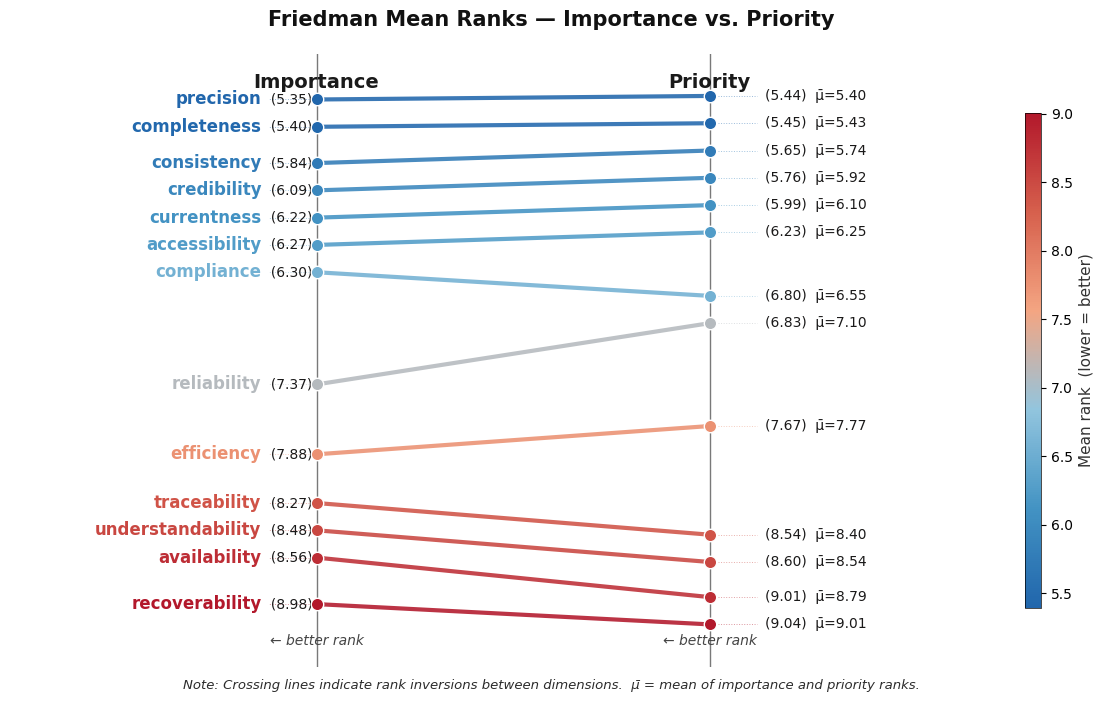

In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_slope_ranks(ranks_df: pd.DataFrame, figsize=(11, 7)) -> plt.Figure:
    df = ranks_df.copy()
    if "mean_rank" not in df.columns:
        df["mean_rank"] = df[["importance_rank", "priority_rank"]].mean(axis=1)
    df = df.sort_values("mean_rank", ascending=False)

    all_ranks = pd.concat([df["importance_rank"], df["priority_rank"]])
    vmin, vmax = all_ranks.min(), all_ranks.max()

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "pub", ["#2166AC", "#4393C3", "#92C5DE", "#F4A582", "#D6604D", "#B2182B"]
    )
    norm = mcolors.Normalize(vmin=df["mean_rank"].min(), vmax=df["mean_rank"].max())

    def spread_positions(values, min_gap=0.20):
        sorted_idx = np.argsort(values)
        pos = np.array(values, dtype=float)
        for _ in range(500):
            changed = False
            for i in range(len(sorted_idx) - 1):
                a, b = sorted_idx[i], sorted_idx[i + 1]
                if pos[b] - pos[a] < min_gap:
                    mid = (pos[a] + pos[b]) / 2
                    pos[a] = mid - min_gap / 2
                    pos[b] = mid + min_gap / 2
                    changed = True
            if not changed:
                break
        return pos

    y_imp_orig   = df["importance_rank"].values
    y_pri_orig   = df["priority_rank"].values
    y_imp_spread = spread_positions(y_imp_orig)
    y_pri_spread = spread_positions(y_pri_orig)

    y_lo  = min(y_imp_spread.min(), y_pri_spread.min())
    y_hi  = max(y_imp_spread.max(), y_pri_spread.max())
    y_pad = (y_hi - y_lo) * 0.08

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x_left, x_right = 0.0, 1.0
    ax.set_xlim(-0.78, 1.78)
    ax.set_ylim(y_hi + y_pad, y_lo - y_pad)

    for x in (x_left, x_right):
        ax.axvline(x, color="#797979", linewidth=1.0, zorder=0)

    for i, (_, row) in enumerate(df.iterrows()):
        color = cmap(norm(row["mean_rank"]))
        yi_s  = y_imp_spread[i]
        yp_s  = y_pri_spread[i]
        yi_o  = y_imp_orig[i]
        yp_o  = y_pri_orig[i]
        name  = row.name
        mean  = row["mean_rank"]

        # Linha principal
        ax.plot([x_left, x_right], [yi_s, yp_s],
                color=color, linewidth=3.0, alpha=0.88,
                solid_capstyle="round", zorder=3)

        # Pontos
        ax.scatter([x_left, x_right], [yi_s, yp_s],
                   color=color, s=80, zorder=5,
                   edgecolors="white", linewidths=1.0)

        # Guias tracejadas
        ax.plot([x_left - 0.02, x_left - 0.12], [yi_s, yi_s],
                color=color, linewidth=0.7, linestyle=":", alpha=0.45)
        ax.plot([x_right + 0.02, x_right + 0.12], [yp_s, yp_s],
                color=color, linewidth=0.7, linestyle=":", alpha=0.45)

        # ── Label esquerda: "Nome  (5.40)" numa linha só ──────────
        ax.text(x_left - 0.14, yi_s,
                f"{name}",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
        ax.text(x_left - 0.14, yi_s,
                f"  ({yi_o:.2f})",          # espaço + valor colado à direita do nome
                ha="left",  va="center", fontsize=10,
                color="#1A1919")

        # ── Label direita: "(7.10)  μ̄ = 6.55" numa linha só ──────
        ax.text(x_right + 0.14, yp_s,
                f"({yp_o:.2f})  μ̄={mean:.2f}",
                ha="left", va="center", fontsize=10,
                color="#1A1919")

    # Cabeçalhos
    gap = y_pad * 0.45
    ax.text(x_left,  y_hi + y_pad - gap, "← better rank",
            ha="center", va="bottom", fontsize=10, color="#454545", style="italic")
    ax.text(x_right, y_hi + y_pad - gap, "← better rank",
            ha="center", va="bottom", fontsize=10, color="#454545", style="italic")
    ax.text(x_left,  y_lo - y_pad + gap, "Importance",
            ha="center", va="top", fontsize=14, color="#1a1a1a", fontweight="bold")
    ax.text(x_right, y_lo - y_pad + gap, "Priority",
            ha="center", va="top", fontsize=14, color="#1a1a1a", fontweight="bold")

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.016, pad=0.008, aspect=30)
    cbar.set_label("Mean rank  (lower = better)", fontsize=11, color="#333333")
    cbar.ax.tick_params(labelsize=10)
    cbar.outline.set_linewidth(0.5)

    ax.axis("off")

    fig.suptitle(
        "Friedman Mean Ranks — Importance vs. Priority",
        fontsize=15, fontweight="bold", color="#111111", y=0.98
    )
    fig.text(
        0.5, 0.01,
        "Note: Crossing lines indicate rank inversions between dimensions.  "
        "μ̄ = mean of importance and priority ranks.",
        ha="center", fontsize=9.5, color="#2C2C2C", style="italic"
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.97], pad=0.6)
    return fig


fig = plot_slope_ranks(_ranks_df)
"""plt.savefig("slope_ranks_publication.pdf", dpi=300, bbox_inches="tight",
            facecolor="white", format="pdf")
plt.savefig("slope_ranks_publication.png", dpi=300, bbox_inches="tight",
            facecolor="white")"""
plt.show()

In [68]:
# Significant Nemenyi pairs (p < 0.05) by dimension
def list_significant_pairs(result, alpha: float = 0.05) -> pd.DataFrame:
    if result["nemenyi"] is None:
        return pd.DataFrame()
    nem = result["nemenyi"]
    rows = []
    chars = list(nem.index)
    for i, a in enumerate(chars):
        for b in chars[i + 1:]:
            p = float(nem.loc[a, b])
            if p < alpha:
                rows.append({"dim": result["dim"], "a": a, "b": b,
                             "rank_a": float(result["mean_ranks"][a]),
                             "rank_b": float(result["mean_ranks"][b]),
                             "p": p})
    return pd.DataFrame(rows).sort_values("p")

sig_imp = list_significant_pairs(friedman_imp)
sig_pri = list_significant_pairs(friedman_pri)

print(f"Nemenyi significant pairs (p<0.05) — importance: {len(sig_imp)}")
print(f"Nemenyi significant pairs (p<0.05) — priority:   {len(sig_pri)}")

Nemenyi significant pairs (p<0.05) — importance: 10
Nemenyi significant pairs (p<0.05) — priority:   16


## 11. Aggregated skills — % "Above average/Very high"

In [69]:
from IPython.display import display as _display
print("── Importance ──")
_display(sig_imp.reset_index(drop=True))
print("── Priority ──")
_display(sig_pri.reset_index(drop=True))

── Importance ──


,dim,a,b,rank_a,rank_b,p
0,importance,precision,understandability,5.353659,8.475610,0.001786
1,importance,precision,accessibility,5.353659,6.268293,0.002270
2,importance,credibility,understandability,6.085366,8.475610,0.012150
3,importance,credibility,accessibility,6.085366,6.268293,0.014937
4,importance,precision,traceability,5.353659,8.268293,0.016536
5,importance,consistency,understandability,5.841463,8.475610,0.017392
6,importance,consistency,accessibility,5.841463,6.268293,0.021223
7,importance,reliability,understandability,7.365854,8.475610,0.039331
8,importance,precision,currentness,5.353659,6.219512,0.043065
9,importance,accessibility,reliability,6.268293,7.365854,0.047101


── Priority ──


,dim,a,b,rank_a,rank_b,p
0,priority,precision,currentness,5.439024,5.987805,0.002014
1,priority,precision,traceability,5.439024,8.536585,0.002139
2,priority,credibility,currentness,5.756098,5.987805,0.002270
3,priority,credibility,traceability,5.756098,8.536585,0.002409
4,priority,precision,accessibility,5.439024,6.231707,0.005400
5,priority,credibility,accessibility,5.756098,6.231707,0.006037
6,priority,precision,understandability,5.439024,8.597561,0.008845
7,priority,credibility,understandability,5.756098,8.597561,0.009843
8,priority,consistency,currentness,5.646341,5.987805,0.014937
9,priority,consistency,traceability,5.646341,8.536585,0.015719


## 8. Export: Consolidated Tables and Findings

### 8.1 Full Test Results and LaTeX Table

Includes **only** comparisons with p<0.05 or |delta|>=0.33 + small/medium/large magnitude. Maintains transparency: report everything in the replication package, cite only the relevant in the paper.

In [70]:
tests.to_csv(TABLES / "inferential_full.csv", index=False)
spear.to_csv(TABLES / "spearman_full.csv", index=False)
print(f"[saved] tables/inferential_full.csv ({len(tests)} rows)")
print(f"[saved] tables/spearman_full.csv ({len(spear)} rows)")

# LaTeX table only with non-negligible findings (|delta|>=0.33 OR sig)
report = tests[(tests["sig_raw"]) | (tests["delta"].abs() >= 0.33)].copy()
report = report.sort_values(["comparison", "dim", "p"]).reset_index(drop=True)

def format_p(p):
    if pd.isna(p):
        return "--"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

lines = [
    "\\begin{table*}[t]",
    "\\caption{Exploratory subgroup comparisons. Mann\u2013Whitney $U$, Cliff\u2019s $\\delta$ (Romano et al., 2006), $p_{\\text{Holm}}$ corrected by comparison pair. Only rows with $p<0.05$ or $|\\delta|\\geq 0.33$ shown.}",
    "\\label{tab:inferential}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{llllrrlrll}",
    "\\toprule",
    "\\textbf{Comparison} & \\textbf{Dim.} & \\textbf{Characteristic} & \\textbf{Med.} & $\\delta$ & \\textbf{IC$_{95}$} & \\textbf{Mag.} & $U$ & $p$ & $p_{\\text{Holm}}$ \\\\",
    "\\midrule",
]
for _, r in report.iterrows():
    char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
    med_str = f"{r['med1']:.0f} vs {r['med2']:.0f}"
    lines.append(
        f"{r['comparison']} & {r['dim']} & {char} & {med_str} & {r['delta']:+.2f} & [{r['ci_lo']:+.2f},{r['ci_hi']:+.2f}] & {r['magnitude']} & {r['U']:.0f} & {format_p(r['p'])} & {format_p(r['p_holm'])} \\\\"
    )
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table*}"])
(TABLES / "inferential.tex").write_text("\n".join(lines), encoding="utf-8")
print(f"[saved] tables/inferential.tex ({len(report)} rows in paper)")

[saved] tables/inferential_full.csv (104 rows)
[saved] tables/spearman_full.csv (52 rows)
[saved] tables/inferential.tex (21 rows in paper)


In [71]:
_disp_cols = ["comparison", "dim", "characteristic", "med1", "med2",
              "delta", "magnitude", "p", "p_holm"]
display(report[_disp_cols])

,comparison,dim,characteristic,med1,med2,delta,magnitude,p,p_holm
0,>3 projects × ≤3 projects,importance,efficiency,4.0,5.0,-0.555556,large,0.001164,0.015136
1,>3 projects × ≤3 projects,importance,recoverability,3.0,5.0,-0.468599,medium,0.006522,0.078268
2,>3 projects × ≤3 projects,importance,reliability,4.0,5.0,-0.376812,medium,0.016438,0.180817
3,>3 projects × ≤3 projects,priority,efficiency,3.0,4.5,-0.623188,large,0.000434,0.005648
4,>3 projects × ≤3 projects,priority,recoverability,3.0,4.5,-0.550725,large,0.001779,0.021346
5,>3 projects × ≤3 projects,priority,reliability,4.0,5.0,-0.487923,large,0.003413,0.037547
6,>3 projects × ≤3 projects,priority,availability,4.0,4.5,-0.490338,large,0.005318,0.053176
7,>3 projects × ≤3 projects,priority,compliance,3.0,5.0,-0.478261,large,0.005873,0.053176
8,>3 projects × ≤3 projects,priority,accessibility,3.0,4.0,-0.357488,medium,0.041938,0.335504
9,>3 projects × ≤3 projects,priority,understandability,4.0,4.0,-0.338164,medium,0.052808,0.369655


### 8.2 Inferential Summary — Plug-and-Play Text

In [72]:
# Concise text findings
report_text = []
if len(sig_holm):
    for _, r in sig_holm.iterrows():
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f}, p_Holm={r['p_holm']:.3f}."
        )
else:
    report_text.append("No comparison survived Holm correction. Report as exploratory.")

for _, r in interesting.iterrows():
    if not r['sig_holm']:
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f} raw (did not survive Holm) — report as a trend."
        )

(TABLES / "inferential_findings.txt").write_text("\n".join(report_text), encoding="utf-8")
print(f"[saved] tables/inferential_findings.txt ({len(report_text)} lines)")

[saved] tables/inferential_findings.txt (14 lines)


In [73]:
display(
    pd.DataFrame({"finding": report_text})
)

,finding
0,"[>3 projects × ≤3 projects, importance] Effici..."
1,"[>3 projects × ≤3 projects, priority] Reliabil..."
2,"[>3 projects × ≤3 projects, priority] Efficien..."
3,"[>3 projects × ≤3 projects, priority] Recovera..."
4,"[Data scientists × Developers, priority] Curre..."
5,"[>3 projects × ≤3 projects, priority] Availabi..."
6,"[>3 projects × ≤3 projects, priority] Complian..."
7,"[>3 projects × ≤3 projects, importance] Recove..."
8,"[Men × Women, priority] Credibility: $\delta$=..."
9,"[Seniors × Juniors, priority] Efficiency: $\de..."
